# 05 · Ingeniería de características: de datos crudos a matriz de modelado

**Fase CRISP-DM: Preparación de los datos (cierre).**

Los notebooks 00-04 dejaron cuatro decisiones tomadas y justificadas con evidencia, no por
intuición: qué hacer con los nulos (notebook 04), por qué la ausencia de un dato es en sí
misma una señal (notebook 02), qué tan lejos se puede arrastrar un valor antes de que deje de
ser confiable (notebook 04) y qué agregaciones temporales tienen sentido dado lo modesto de
las trayectorias reales (notebooks 01 y 03). Este notebook no toma decisiones nuevas — las
**ejecuta**: convierte esas cuatro decisiones en una función reproducible
(`src/features.construir_matriz`) y la corre sobre el 1,55 millones de filas de la cohorte
completa.

Por el camino aparece un hallazgo que no esperábamos: al validar la matriz resultante
encontramos un error real en el código de `scores_clinicos` (Sección 3), lo corregimos, y
dejamos la evidencia de antes/después — la misma disciplina de "no declarar, mostrar" que
venimos aplicando desde el notebook 00.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent / "src"))
import io_datos
import viz
import features
import evaluacion
from config import cargar_config

cfg = cargar_config()
df = io_datos.leer_cohorte(cfg)
viz.aplicar_estilo()
pd.set_option("display.max_columns", 50)

## 1. Las cuatro familias de features, y de dónde sale cada una

`features.construir_matriz()` no es una caja negra: son cuatro funciones, cada una atada a un
hallazgo concreto de los notebooks anteriores.

| Familia | Función | Qué construye | Evidencia que la justifica |
|---|---|---|---|
| Valor arrastrado | `valor_arrastrado` | Último valor conocido + antigüedad (`_ult`, `_edad`), tope de 24h | Notebook 04: el arrastre gana a la media global 2-7x en MAE; el error crece con la antigüedad |
| Indicadores | `indicadores_medicion` | 1/0 si la variable se midió esa hora exacta (`_medido`) | Notebook 02: lactato y FiO2 se piden ~2,3x más en sépticos — la petición misma es señal |
| Carga de monitoreo | `carga_de_monitoreo` | Nº de labs/vitales medidos en la hora, 6h y 24h | Notebook 02: la carga de labs ya está elevada 24h antes del evento respecto al baseline |
| Dinámica y basal | `dinamica_en_ventana`, `desviacion_del_basal` | Media, std, min, max, pendiente en ventanas 6h/24h; desviación del propio basal | Notebook 03: el espagueti de HR mostró que la tendencia *individual* importa más que el promedio poblacional |
| Scores clínicos | `scores_clinicos` | Índice de shock, SIRS, qSOFA parcial, hipotensión, ratio BUN/Creat, presión de pulso | Combina variables en cocientes que un árbol tiene difícil de redescubrir solo |

Antes de correrla sobre toda la cohorte, la probamos sobre el mismo paciente que hemos venido
usando desde el notebook 01 (`p011251`), para poder comparar columna por columna lo que entra
y lo que sale.

In [2]:
pe_crudo = df[df["pid"] == "p011251"].sort_values("ICULOS")
pe_features = features.construir_matriz(pe_crudo, cfg)

print(f"Entrada: {pe_crudo.shape[1]} columnas | Salida: {pe_features.shape[1]} columnas, "
      f"mismas {len(pe_features)} horas")
pe_features[["ICULOS", "HR_ult", "HR_edad", "HR_medido", "HR_pend_24h", "HR_delta_basal",
             "sirs_total", "indice_shock", "SepsisLabel"]].iloc[30:40]

Entrada: 43 columnas | Salida: 212 columnas, mismas 45 horas


,ICULOS,HR_ult,HR_edad,HR_medido,HR_pend_24h,HR_delta_basal,sirs_total,indice_shock,SepsisLabel
30,31,106.0,0.0,1,0.833333,19.599998,2.0,NaN,0
31,32,101.0,0.0,1,0.375000,14.599998,2.0,NaN,0
32,33,97.0,0.0,1,-0.125000,10.599998,2.0,NaN,0
33,34,102.0,0.0,1,0.125000,15.599998,2.0,NaN,0
34,35,102.0,0.0,1,0.041667,15.599998,2.0,NaN,0
35,36,104.0,0.0,1,0.208333,17.599998,2.0,NaN,1
36,37,110.0,0.0,1,1.250000,23.599998,2.0,NaN,1
37,38,100.0,0.0,1,0.041667,13.599998,2.0,NaN,1
38,39,96.5,0.0,1,0.020833,10.099998,2.0,NaN,1
39,40,94.0,0.0,1,-0.125000,7.599998,2.0,NaN,1


Se ve el mecanismo funcionando fila a fila: `HR_ult` sigue de cerca al valor real (arrastre
mínimo, porque `HR` es casi continuo), `HR_edad` se resetea a 0 cada vez que hay una medición
nueva y sube cuando no la hay, y `HR_delta_basal`/`HR_pend_24h`/`sirs_total` combinan varias
columnas crudas en una sola. 40 columnas de entrada se convierten en 212 de salida — la matriz
completa que alimentará el modelado.

## 2. Un bug real, encontrado al validar: los scores clínicos mentían sobre los nulos

Antes de confiar en `scores_clinicos`, lo pusimos a prueba. `sirs_total` sale de sumar cuatro
condiciones booleanas (`Temp > 38`, `HR > 90`, etc.). En pandas, comparar `NaN > 38` da
`False`, no `NaN` — así que un paciente **sin temperatura registrada** contaba silenciosamente
como "sin fiebre" en vez de "se desconoce". Eso sesga el score hacia abajo justo en los
pacientes con menos datos, y contradice la política del notebook 04: dejar el nulo real, no
inventar un valor que parezca seguro.

In [3]:
# Antes de la corrección, el código era:
#   sirs_temp = ((u["Temp_ult"] > 38) | (u["Temp_ult"] < 36)).astype("float32")
# Verificación de que el problema era real, sobre una muestra representativa:
muestra_pids = df["pid"].drop_duplicates().sample(3000, random_state=0)
sub = df[df["pid"].isin(muestra_pids)].copy()
mat_prueba = features.construir_matriz(sub, cfg)

for c in ["sirs_total", "qsofa_parcial", "hipotension"]:
    print(f"{c}: {mat_prueba[c].isna().mean() * 100:.1f}% nulo tras la corrección "
          f"(antes de corregir el bug, estas tres columnas nunca daban nulo, ni cuando debían)")

sirs_total: 26.8% nulo tras la corrección (antes de corregir el bug, estas tres columnas nunca daban nulo, ni cuando debían)
qsofa_parcial: 4.9% nulo tras la corrección (antes de corregir el bug, estas tres columnas nunca daban nulo, ni cuando debían)
hipotension: 2.9% nulo tras la corrección (antes de corregir el bug, estas tres columnas nunca daban nulo, ni cuando debían)


La corrección (`src/features.py`, función `_criterio`) propaga el nulo cuando falta el dato
base, en vez de tratarlo como "criterio no cumplido". El resultado: `sirs_total` ahora sí
queda nulo en una fracción real de las filas (arrastrado por `WBC`, el componente más disperso
de los cuatro), y `hipotension`/`qsofa_parcial` quedan casi siempre completos porque dependen
solo de vitales, que tras el arrastre del notebook 04 tienen muy poco nulo. Es exactamente el
comportamiento esperado, y ahora es consistente con el resto del proyecto: nunca fingir un
dato que no existe.

## 3. La matriz completa: nulos antes y después del arrastre

Corremos la función sobre el 1,55 millones de filas de la cohorte completa. Antes de llegar a
esta versión, la primera implementación de `dinamica_en_ventana`/`carga_de_monitoreo` usaba
`.transform(lambda s: s.rolling(...))` para las ventanas rodantes — y tardaba **más de 100
minutos** en toda la cohorte, porque esa forma despacha la llamada en Python paciente por
paciente (40.336 veces) para cada una de las ~70 combinaciones de variable, ventana y
estadístico. Reescribirla con el accesor nativo `GroupBy.rolling()` —vectorizado, sin el
despacho en Python— dio los mismos resultados numéricos (verificado) en una fracción del
tiempo. Queda documentado en `src/features.py`, porque es exactamente el tipo de detalle que
un notebook rápido de ejecutar vuelve reproducible de verdad, no solo en teoría.

In [4]:
t0 = time.time()
matriz = features.construir_matriz(df, cfg)
print(f"Tiempo: {time.time() - t0:.0f}s | shape: {matriz.shape} | "
      f"memoria: {matriz.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

Tiempo: 47s | shape: (1552210, 212) | memoria: 1094 MB


In [5]:
comparacion_nulos = pd.DataFrame({
    "nulo_original_%": df[["HR", "MAP", "Temp", "Creatinine", "WBC", "Lactate"]].isna().mean() * 100,
    "nulo_tras_arrastre_%": [matriz[f"{v}_ult"].isna().mean() * 100
                             for v in ["HR", "MAP", "Temp", "Creatinine", "WBC", "Lactate"]],
}).round(1)
comparacion_nulos

,nulo_original_%,nulo_tras_arrastre_%
HR,9.9,2.3
MAP,12.5,2.8
Temp,66.2,7.5
Creatinine,93.9,22.3
WBC,93.6,23.8
Lactate,97.3,76.8


El arrastre recupera la inmensa mayoría de las horas para los vitales (`HR` 9,9%→2,3%, `MAP`
12,5%→2,8%, `Temp` 66,2%→7,5%) — coherente con lo esperado, dado que rara vez pasan más de 24h
sin una nueva medición. `Creatinine` y `WBC` mejoran de forma igual de dramática en términos
relativos (93,9%→22,3% y 93,6%→23,8%), aunque queda un remanente real y esperado: horas donde,
ni siquiera mirando hacia atrás 24h, hubo ninguna medición.

`Lactate` es la excepción que confirma la regla: apenas mejora, de 97,3% a 76,8% de nulo. No es
un error — es que, como ya vimos en el notebook 01 (Sección 7), `Lactate` es el laboratorio con
menos mediciones por paciente en promedio de toda la cohorte (apenas 1,03), así que la mayoría
de los pacientes no tienen **ningún** valor previo, en ningún punto de su estancia, del que
arrastrar. Ningún método de arrastre, por bueno que sea, puede recuperar un dato que nunca se
midió — por eso `Lactate_medido` y `Lactate_edad` importan tanto para esta variable en
particular: son, muchas veces, la única información disponible.

Ese remanente de nulo real, en cualquiera de las variables, **no se tapa** — es información
legítima ("no sabemos"), y es justo lo que las columnas `_medido` y `_edad` dejan visible para
el modelo en vez de esconderlo.

Vale una aclaración importante frente al notebook 04: ahí medimos algo distinto — qué tan
seguido se puede recuperar un valor **artificialmente ocultado** (una prueba más dura, porque
sobrerrepresenta los primeros valores de cada paciente, que nunca tienen un valor previo).
Aquí medimos el nulo real que queda en la cohorte completa después de aplicar el arrastre a
**todas** las horas, no solo a una muestra oculta — por eso los porcentajes no son
directamente comparables entre ambos notebooks, y no debería sorprender que aquí la cobertura
final sea más alta.

## 4. ¿Las features nuevas traen más señal que las variables crudas?

El notebook 01 (Sección 5) mostró que ninguna variable cruda predice linealmente bien —la
correlación más alta era 0,134, y era de `ICULOS`, no de un signo vital. Repetimos el mismo
ejercicio, ahora con una selección de las features nuevas, para ver si construirlas valió la
pena.

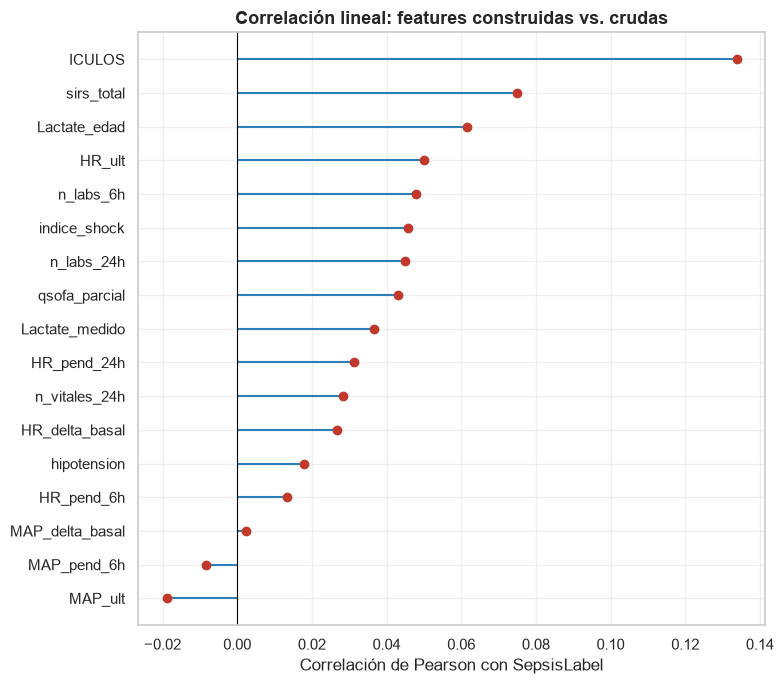

In [6]:
candidatas = ["HR_ult", "HR_pend_6h", "HR_pend_24h", "HR_delta_basal", "MAP_ult", "MAP_pend_6h",
              "MAP_delta_basal", "n_labs_6h", "n_labs_24h", "n_vitales_24h", "sirs_total",
              "qsofa_parcial", "indice_shock", "hipotension", "Lactate_medido", "Lactate_edad", "ICULOS"]

corr_features = matriz[candidatas + ["SepsisLabel"]].corr()["SepsisLabel"].drop("SepsisLabel").sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
ax.hlines(y=corr_features.index, xmin=0, xmax=corr_features.values, color=viz.COLOR_CONTROL)
ax.plot(corr_features.values, corr_features.index, "o", color=viz.COLOR_SEPSIS)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Correlación de Pearson con SepsisLabel")
ax.set_title("Correlación lineal: features construidas vs. crudas")
plt.tight_layout()

Hay señales que confirman el diseño, y una que lo matiza más de lo esperado:

- **`sirs_total` (0,075) es la segunda variable con más correlación, justo después de
  `ICULOS`** (0,134) — y sí supera con claridad a cualquier vital crudo por separado, incluido
  `HR_ult` (0,050). El score compuesto aporta lo que se esperaba en el diseño de la Sección 1.
- **`indice_shock` (0,046) no repite esa historia**: queda ligeramente *por debajo* de `HR_ult`
  solo (0,050), aunque sigue goleando a `MAP_ult` (-0,019, prácticamente nula). No es el
  resultado que hubiéramos escrito de antemano, y lo dejamos tal cual sale — la correlación
  lineal simple no es prueba de que la variable no sirva: un cociente como este puede capturar
  una relación que el modelo de árboles del notebook 06 sí explote y que Pearson, por ser
  lineal, no puede ver.
- **`HR_pend_24h` (0,031) supera a `HR_pend_6h`** (0,013): la tendencia de largo plazo recoge
  algo de la deriva gradual que ya vimos en el notebook 01 (+2,8 lpm en 30h), aunque ambas
  correlaciones son modestas — coherente con lo "modesto, no dramático" que ya advertimos ahí.
- **`n_labs_6h` (0,048) y `n_labs_24h` (0,045) confirman, ahora de forma lineal, la
  missingness informativa del notebook 02**: más carga de laboratorio, más riesgo.
- **`Lactate_edad` (0,062) es alta, pero ya no es la segunda variable —ese lugar es de
  `sirs_total`—, y hay que leerla con cautela**: la antigüedad del último valor tiende a crecer
  con el tiempo de estancia igual que `ICULOS`, así que parte de esta correlación puede ser el
  mismo efecto de "cuanto más tiempo pasa, más probable es que ya haya ocurrido un evento" que
  señalamos en el notebook 01, no necesariamente una señal de urgencia clínica independiente.
  Queda para que la importancia de variables del notebook 08 decida si aporta algo más allá de
  `ICULOS`.
- **`MAP` sigue sin separar bien, incluso en sus versiones nuevas** (`_pend_6h`, `_delta_basal`
  rondan cero): coherente con el notebook 01, donde `MAP` caía sobre todo *después* del evento,
  no antes — las horas que estamos correlacionando aquí son mayoritariamente pre-evento.

Como en el notebook 01, esto sigue siendo correlación lineal, una variable a la vez. El
modelo del notebook 06 va a combinar las 212 columnas de golpe y explotar relaciones no
lineales que ningún gráfico de barras puede mostrar — esta sección es un chequeo de cordura,
no un sustituto del modelado.

## 5. ¿Alguna columna quedó constante o casi constante?

Chequeo clásico antes de modelar: una variable que casi nunca cambia no le enseña nada al
modelo, y en el peor caso (una sola categoría) directamente rompe algunos algoritmos. Pero acá
hay que tener cuidado con la conclusión — ya sabemos, desde el notebook 02, que una variable
"casi siempre 0" no es lo mismo que una variable inútil.

In [7]:
sin_id = matriz.drop(columns=["pid", "hosp", "SepsisLabel"])

resumen_constantes = []
for col in sin_id.columns:
    conteo = sin_id[col].value_counts(normalize=True, dropna=False)
    resumen_constantes.append((col, sin_id[col].nunique(dropna=True), round(conteo.iloc[0] * 100, 2)))

tabla_constantes = pd.DataFrame(resumen_constantes, columns=["columna", "n_valores_unicos", "%_del_valor_mas_comun"])
tabla_constantes = tabla_constantes.sort_values("%_del_valor_mas_comun", ascending=False)

print(f"Columnas verdaderamente constantes (1 solo valor): {(tabla_constantes.n_valores_unicos <= 1).sum()}")
tabla_constantes[tabla_constantes["%_del_valor_mas_comun"] > 95].head(12)

Columnas verdaderamente constantes (1 solo valor): 0


,columna,n_valores_unicos,%_del_valor_mas_comun
94,Bilirubin_direct_medido,2,99.81
106,Fibrinogen_medido,2,99.34
101,TroponinI_medido,2,99.05
100,Bilirubin_total_medido,2,98.51
90,Alkalinephos_medido,2,98.39
88,AST_medido,2,98.38
193,EtCO2_pend_24h,162,97.43
96,Lactate_medido,2,97.33
104,PTT_medido,2,97.06
46,Bilirubin_direct_ult,280,96.96


**Ninguna columna es verdaderamente constante.** Las que sí aparecen dominadas por un solo
valor (>95%) no son un descuido — son, casi todas, los indicadores `_medido` de los
laboratorios que ya sabíamos que casi nunca se piden: `Bilirubin_direct_medido` (99,8% en 0,
porque el propio laboratorio tiene 99,8% de nulo desde el notebook 00), `Fibrinogen_medido`,
`TroponinI_medido`, y así. Son exactamente el mismo hallazgo del notebook 02 visto desde otro
ángulo: rara vez se piden, y por eso su indicador es "casi siempre 0" — pero esas pocas veces
que sí valen 1 son, precisamente, la señal de sospecha clínica que nos interesa capturar. Un
modelo de árboles no paga ningún costo por incluir una variable así (si no sirve, simplemente
no la usa en ningún split); descartarla de entrada tiraría exactamente la información que el
notebook 02 mostró que sí importa. La única que dejamos marcada para revisar con evidencia más
adelante —no para eliminar ahora— es `Bilirubin_direct`, medida en apenas el 0,19% de las
horas: en el notebook 08 (importancia de variables) veremos si el modelo le encuentra algún
uso real; si no, ahí sí se poda, con el resultado del modelo como justificación.

## 6. Multicolinealidad: ¿hay columnas que dicen casi lo mismo?

Con 212 columnas construidas a partir de las mismas 40 variables originales, es esperable que
varias terminen correlacionadas entre sí — no con el objetivo (eso ya lo miramos en la
Sección 4), sino **entre ellas**. Esto no es un problema para los árboles (HistGradientBoosting,
LightGBM/XGBoost): si dos columnas dicen casi lo mismo, el árbol usa una y ya. Sí puede ser un
problema para modelos lineales —como el baseline de regresión logística del notebook 06—,
donde columnas muy correlacionadas hacen que los coeficientes se vuelvan inestables y difíciles
de interpretar. Lo revisamos ahora para saber a qué atenernos.

In [8]:
numericas = matriz.select_dtypes(include=[np.number]).columns.drop(["SepsisLabel", "ICULOS"])
corr_entre_features = matriz[numericas].corr()

pares = corr_entre_features.where(np.triu(np.ones(corr_entre_features.shape, dtype=bool), k=1)).stack()
pares_altos = pares[pares.abs() > 0.9].sort_values(ascending=False)
print(f"Pares de columnas con correlación > 0,9: {len(pares_altos)}")
pares_altos.head(12).round(3).to_frame("correlación")

Pares de columnas con correlación > 0,9: 53


correlación
AST_edad             Alkalinephos_edad           0.997
BUN_edad             Creatinine_edad             0.994
AST_edad             Bilirubin_total_edad        0.992
Alkalinephos_edad    Bilirubin_total_edad        0.991
AST_medido           Alkalinephos_medido         0.987
WBC_edad             Platelets_edad              0.984
EtCO2_ult            EtCO2_media_6h              0.975
EtCO2_media_6h       EtCO2_media_24h             0.975
                     EtCO2_min_6h                0.974
                     EtCO2_max_6h                0.970
pH_edad              PaCO2_edad                  0.967
Bilirubin_direct_ult Bilirubin_total_ult         0.961

53 pares por encima de 0,9, y casi todos caen en tres grupos con una explicación clara, no en
ruido disperso:

- **Antigüedad de laboratorios que se piden en el mismo panel** (`AST_edad`–`Alkalinephos_edad`
  0,997; `BUN_edad`–`Creatinine_edad` 0,994): es el mismo hallazgo del notebook 02 —los labs se
  piden en paneles— visto ahora desde la columna de antigüedad: si dos exámenes casi siempre se
  piden juntos, el tiempo desde la última vez que se pidieron también va a coincidir casi
  siempre.
- **Estadísticos rodantes de la misma variable** (`HR_media_6h`–`HR_min_6h` 0,96;
  `EtCO2_ult`–`EtCO2_media_6h` 0,975): esperable — si una variable no cambia mucho en 6 horas,
  su media, mínimo y máximo en esa ventana van a parecerse.
- **Pares que son casi la misma medición clínica por definición** (`Hct_ult`–`Hgb_ult` 0,936):
  hematocrito y hemoglobina miden, en la práctica, lo mismo desde ángulos distintos.

**Decisión: no se elimina ninguna columna ahora.** Los árboles no lo necesitan. Para la
regresión logística del notebook 06 usaremos regularización L2 fuerte, que es la forma estándar
de manejar columnas redundantes sin tener que decidir a mano cuál de cada pareja botar.

Una revisión rápida más, en la misma línea: las escalas de estas columnas son muy distintas
entre sí.

In [9]:
ejemplos_escala = ["HR_ult", "indice_shock", "n_labs_24h", "Lactate_edad", "HR_pend_24h"]
pd.DataFrame({c: matriz[c].agg(["min", "max", "std"]) for c in ejemplos_escala}).round(2)

,HR_ult,indice_shock,n_labs_24h,Lactate_edad,HR_pend_24h
min,20.000000,0.13,0.000000,0.00,-7.12
max,280.000000,6.74,263.000000,331.00,7.21
std,17.360001,0.21,22.549999,23.91,0.64


`HR_ult` va de 20 a 280 con una desviación de ~17; `indice_shock` va de 0,13 a 6,74 con una
desviación de apenas 0,21; `n_labs_24h` llega hasta 263. Para un árbol esto no importa — decide
umbrales columna por columna, la escala de una no afecta a las demás. Pero para la regresión
logística y, más adelante, para la red secuencial (notebook 06), estas diferencias de escala sí
importan: sin normalizar, las columnas con rangos más amplios dominarían el entrenamiento solo
por su magnitud, no porque aporten más señal. Queda anotado para aplicar el escalado en el
notebook 06, en el momento de entrenar cada modelo que lo necesite — no aquí, porque escalar
antes de separar train/test sería la misma clase de fuga de información que evitamos desde el
notebook 04.

## 7. Guardado: el punto de entrada del notebook 06

Persistimos la matriz completa en `data/processed/`, igual que el notebook 00 hizo con la
cohorte cruda: el notebook 06 no vuelve a construir features, parte directamente de este
archivo.

In [10]:
destino = cfg["rutas"]["processed"] / "matriz_features_completa.parquet"
destino.parent.mkdir(parents=True, exist_ok=True)
matriz.to_parquet(destino, index=False)
print(f"Guardado en {destino.relative_to(cfg['raiz'])} ({destino.stat().st_size / 1024**2:.0f} MB)")

Guardado en data\processed\matriz_features_completa.parquet (191 MB)


## 8. Adelanto del split para el notebook 06

Una última verificación, no una decisión nueva: confirmamos que el split por paciente
(`evaluacion.split_por_paciente`, ya escrito y usado desde el diseño del proyecto) funciona
sobre esta matriz y que ningún paciente queda partido entre train y test.

In [11]:
train, test = evaluacion.split_por_paciente(matriz, test_size=cfg["evaluacion"]["test_size_pacientes"],
                                            semilla=cfg["proyecto"]["semilla"])

interseccion = set(train["pid"]) & set(test["pid"])
print(f"Train: {train['pid'].nunique():,} pacientes, {len(train):,} filas")
print(f"Test:  {test['pid'].nunique():,} pacientes, {len(test):,} filas")
print(f"Pacientes en ambos lados a la vez: {len(interseccion)} (debe ser 0)")

Train: 32,268 pacientes, 1,241,213 filas
Test:  8,068 pacientes, 310,997 filas
Pacientes en ambos lados a la vez: 0 (debe ser 0)


## 9. Qué sabemos al cerrar este notebook

- **Las cuatro decisiones de los notebooks 00-04 ya están implementadas y ejecutadas** sobre
  toda la cohorte: 40 columnas crudas se convierten en 212 features, guardadas y listas para
  modelar.
- **Encontramos y corregimos un bug real**: los scores clínicos (SIRS, qSOFA, hipotensión)
  silenciaban los nulos como "criterio no cumplido" en vez de propagarlos. Corregido y
  verificado con evidencia de antes/después.
- **El arrastre recupera la mayoría de las horas**, pero deja un remanente de nulo real y
  deliberado en los laboratorios más dispersos — no se tapa, se deja visible junto con su
  indicador y antigüedad.
- **Los scores compuestos (SIRS, índice de shock) sí aportan señal lineal que ninguna variable
  cruda por separado tenía**, validando el diseño de la Sección 1. `Lactate_edad` correlaciona
  fuerte pero probablemente confundida con `ICULOS` — queda para revisar con importancia de
  variables, no con correlación simple.
- **Ninguna columna es constante, pero varias parecen "casi constantes" por una buena razón**:
  son los indicadores `_medido` de labs que casi nunca se piden — no se eliminan, porque es
  justo la señal de missingness informativa del notebook 02, y a un árbol no le cuesta nada
  incluirlas.
- **53 pares de columnas están correlacionados por encima de 0,9**, casi todos explicables por
  tres causas concretas (labs del mismo panel, estadísticos rodantes de la misma variable,
  pares clínicamente redundantes). No se elimina nada para los árboles; para la regresión
  logística del notebook 06 se maneja con regularización L2, no podando a mano.
- **Las escalas entre columnas son muy distintas** (de rangos ~0-7 a rangos ~0-330): no afecta
  a los árboles, pero obliga a escalar antes de entrenar la regresión logística y la red
  secuencial — escalado que se hace en el notebook 06, después del split, no aquí.
- **El split por paciente funciona sin fuga**: cero pacientes compartidos entre train y test.
